This notebook shows how to use [OmniCloudMask](https://github.com/DPIRD-DMA/OmniCloudMask) for masking Sentinel-2 images. OmniCloudMask is a deep-learning based cloud and cloud-shadow segmentation package and provides a high quality cloud mask. You will learn how to use it to mask cloudy pixels on a single scene as well use Dask to process a time-series of scenes.

> Note: For the best performance, run this notebook on a machine with a GPU. On Colab, you can switch your runtime type to a T4 GPU.

### Setup

Determine our runtime environment.

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install pystac-client odc-stac rioxarray dask['distributed'] \
        jupyter-server-proxy odc-algo botocore omnicloudmask

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pyproj
import pystac_client
import rioxarray as rxr
import torch
import xarray as xr
from matplotlib.colors import ListedColormap
from odc.stac import configure_s3_access, load
from omnicloudmask import predict_from_array

OmniCloudMask uses a pre-trained neural network to predict the mask and hence is it best run on a machine with a GPU. We first check and configure the backend available and download the model.

> If this cell gets stuck waiting to download the model, stopping and re-running fixes it.

In [ ]:
inference_device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Inference device: {inference_device}')

# Set the Hugging Face token if you have one.
# This speeds up the download of the model weights from Hugging Face Hub.
HF_TOKEN = ''
if HF_TOKEN:
    os.environ['HF_TOKEN'] = HF_TOKEN

# Run a test prediction
# This will download the model weights locally
# and warms up the model for inference.
predict_from_array(
    np.zeros((3, 50, 50), dtype=np.float32), inference_device=inference_device
)


Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client

# As we are using GPU inference, we use a single worker client
client = Client(
    n_workers=1,
    threads_per_worker=2,
)
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Masking a Single Scene

If a scene fits into memory, this approach is the most straightforward one. Let's learn this approach first and then we will see how we can scale this to a time-series.


We define a location and time of interest to get some satellite imagery.

In [ ]:
latitude = 27.163
longitude = 82.608
year = 2023

Get a single cloudy scene. We load the Sentinel-2 data at 20m resolution instead of 10m. This performs better and faster. See [Choosing a Resolution](https://omnicloudmask.readthedocs.io/en/latest/resolution.html) for more guidance.

In [ ]:
# Define a GeoJSON geometry
geometry = {
    'type': 'Point',
    'coordinates': [longitude, latitude]
}

# Query the STAC Catalog
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

configure_s3_access(
    aws_unsigned=True,
)
search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=f'{year}',
    query={
        'eo:cloud_cover': {'lt': 50},
        's2:nodata_pixel_percentage': {'lt': 10}},
    sortby=[
        {'field': 'properties.eo:cloud_cover',
         'direction': 'desc'}
        ]
)
items = search.item_collection()

# Items were sorted in descending order of cloud cover,
# so the first item is the most cloudy
most_cloudy = items[0]

ds = load(
    [most_cloudy],
    bands=['red', 'green', 'blue', 'nir', 'scl'],
    resolution=20, # Load the data at lower resolution to speed up processing
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    groupby='solar_day',
    preserve_original_order=True
)

scene = ds.squeeze()
# Mask nodata values
scene = scene.where(scene != 0)

# Apply scale/offset
scale = 0.0001
offset = -0.1
# Select spectral bands (all except 'scl')
data_bands = [band for band in scene.data_vars if band != 'scl']
for band in data_bands:
  scene[band] = scene[band] * scale + offset
scene

Let’s call `compute()` to kick-off the dask graph. Dask will query the cloud-hosted dataset to fetch the required pixels. Once you run the cell, look at the Dask Diagnostic Dashboard to see the data processing in action.

In [ ]:
%%time
scene = scene.compute()

#### Apply SCL Mask

We use the bundled  Scene Classification (SCL) band for masking cloudy pixels. We select the types of pixels we want to mask. Let's create a mask that will remove all pixels marked `Cloud shadows (3)`, `Cloud Medium Probability (8)`, `Cloud High Probability (9)` and `Thin Cirrus (10)`.

In [ ]:
scl_mask = scene['scl'].isin([3,8,9,10])

We apply mask to all the data bands.

In [ ]:
scene_masked_scl = scene[data_bands].where(~scl_mask)

#### Apply OmniCloudMask

[OmniCloudMask](https://omnicloudmask.readthedocs.io/en/latest/index.html) uses a pre-trained Deep Learning model to predict clouds from satellite imagery. It supports resolutions from 10 m to 50 m and works with any imagery that has Red, Green, and NIR bands. Select the required bands from our scene and convert to a DataArray to be passed on for prediction.

In [ ]:
ocm_input = scene[['red', 'green', 'nir']] \
    .to_array('band') \
    .values

Now we use OmniCloudMask's [predict_from_array()](https://omnicloudmask.readthedocs.io/en/latest/api.html#predict-from-array) function to get the predicted cloud mask. This will also download the model weights locally on the first call.


In [ ]:
%%time
ocm_prediction = predict_from_array(ocm_input,  inference_device=inference_device)
ocm_prediction_da = xr.DataArray(
    ocm_prediction,
    dims=('mask', 'y', 'x'),
    coords={'y': scene.y, 'x': scene.x, 'spatial_ref': scene.spatial_ref},
).squeeze()

The result contains following values.

 Value | Description                                  |
|-------|---------------------------------------------|
| 0     | Clear                                       |
| 1     | Thick Cloud                                 |
| 2     | Thin Cloud                                  |
| 3     | Cloud Shadow                                |

We select all non-clear pixels as the mask.


In [ ]:
ocm_mask_da = ocm_prediction_da.isin([1, 2, 3])

Apply the mask to all the data bands.

In [ ]:
scene_masked_ocm = scene[data_bands].where(~ocm_mask_da)

#### Visualize the Results

Let's visualize and compare both the masks.


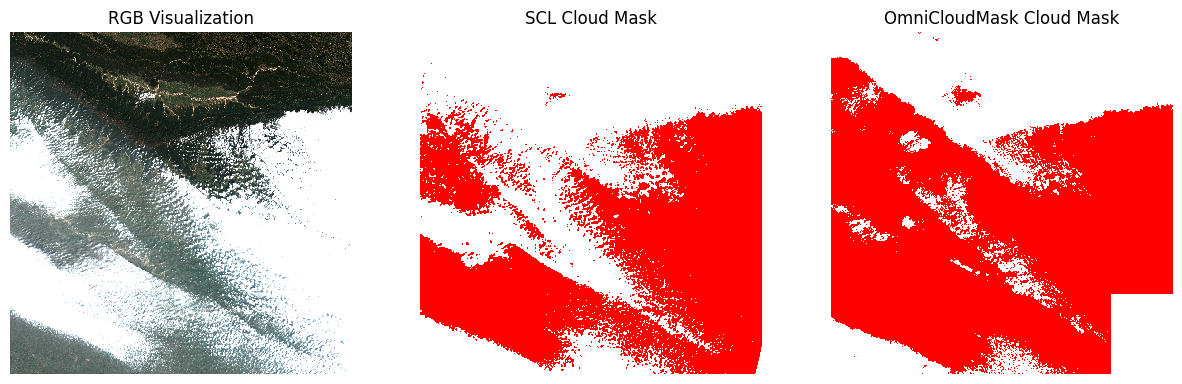

In [99]:
scene_preview = scene[['red', 'green', 'blue']].to_array('band')\
  .rio.reproject(
    scene.rio.crs, resolution=100
)
scl_mask_preview = scl_mask.astype('uint8').rio.reproject(
    scl_mask.rio.crs, resolution=100
)
ocm_mask_preview = ocm_mask_da.astype('uint8').rio.reproject(
    ocm_mask_da.rio.crs, resolution=100
)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3)
fig.set_size_inches(15,5)
scene_preview.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax0,
    vmin=0, vmax=0.3)
ax0.set_title('RGB Visualization')

# RGBA: Transparent, Red
mask_colormap = ListedColormap(['#00000000', '#FF0000FF'])
scl_mask_preview.plot.imshow(
    ax=ax1,
    cmap=mask_colormap,
    add_colorbar=False)

ax1.set_title('SCL Cloud Mask')
ocm_mask_preview.plot.imshow(
    ax=ax2,
    cmap=mask_colormap,
    add_colorbar=False)
ax2.set_title('OmniCloudMask Cloud Mask')

for ax in (ax0, ax1, ax2):
  ax.set_axis_off()
  ax.set_aspect('equal')
plt.show()

#### Save the Masked Scene

In [ ]:
scl_mask_file = f'scene_scl_masked.tif'
ocm_mask_file = f'scene_ocm_masked.tif'
scl_mask_path = os.path.join(output_folder, scl_mask_file)
ocm_mask_path = os.path.join(output_folder, ocm_mask_file)

scene_masked_scl.to_array(dim='band').rio.to_raster(scl_mask_path, driver='COG')
scene_masked_ocm.to_array(dim='band').rio.to_raster(ocm_mask_path, driver='COG')

### Masking a Time-Series

Now, let's see how we can predict the OmniCloudScore cloud mask for all the scenes in a time-series. This will require us to use Dask and process the required pixels in chunks.

Let's query and get all the scenes for one year.

In [ ]:
# Define a GeoJSON geometry
geometry = {
    'type': 'Point',
    'coordinates': [longitude, latitude]
}

# Query the STAC Catalog
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

configure_s3_access(
    aws_unsigned=True,
)

search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=f'{year}',
    query={
        'eo:cloud_cover': {'lt': 30},
        's2:nodata_pixel_percentage': {'lt': 10}}
)
items = search.item_collection()


ds = load(
    items,
    bands=['red', 'green', 'blue', 'nir', 'scl'],
    resolution=20, # Load the data at lower resolution to speed up processing
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    groupby='solar_day',
    preserve_original_order=True
)

# Mask nodata values
ds = ds.where(ds != 0)

# Apply scale/offset
scale = 0.0001
offset = -0.1
# Select spectral bands (all except 'scl')
data_bands = [band for band in ds.data_vars if band != 'scl']
for band in data_bands:
  ds[band] = ds[band] * scale + offset
ds

Unlike SCL, OmniCloudMask cannot be broadcast over `time`, as it needs to run the model on each scene array. The model requires at least a `50px x 50px` of spatial context for prediction - with the recommended array size being `1000px x 1000px`. We can chunk our input data cube and run the prediction on each chunk independently. This will ensure that only the chunks intersecting our area of interest gets processed and not the whole scene.

In [ ]:
ocm_input = ds[['red', 'green', 'nir']] \
    .to_array('band') \
    .chunk({
      'time': 1, # One time step per chunk
      'band': -1 # All bands in a single chunk
    })

def ocm_predict_block(block):
  # block arrives as (band=3, time=1, y, x)
  # drop the time dimension to get (band=3, y, x)
  ocm_input =  block[:, 0]
  ocm_prediction = predict_from_array(ocm_input,  inference_device=inference_device)
  return ocm_prediction

# map_blocks runs the per-chunk prediction on the Data array
ocm_mask_data = ocm_input.data.map_blocks(
    ocm_predict_block,
    drop_axis=0,  # band axis is consumed by the prediction
    dtype=np.uint8,
)

# Reconstruct the DataArray with the same coordinates
# and dimensions as the original input
ocm_prediction_ts = xr.DataArray(
    ocm_mask_data,
    dims=('time', 'y', 'x'),
    coords={'time': ocm_input.time,
             'y': ocm_input.y,
             'x': ocm_input.x,
             'spatial_ref': ocm_input.spatial_ref
            },
)

Keep only the clear pixels form the predicted mask.

In [ ]:
ocm_mask_ts = ocm_prediction_ts.isin([1, 2, 3])

Apply the predicted mask.

In [ ]:
ds_masked_ocm = ds.where(~ocm_mask_ts)
ds_masked_ocm

### Extract a Cloud-Masked NDVI Time Series

Following the course's [time-series workflow](#extracting-and-processing-time-series), we extract an NDVI time series at a point of interest from the masked stack.

Calculate NDVI and add it as a data variable.

In [ ]:
red = ds_masked_ocm['red']
nir = ds_masked_ocm['nir']

ndvi = (nir - red)/(nir + red)
ds_masked_ocm['ndvi'] = ndvi
ds_masked_ocm

Our location coordinates are in EPSG:4326 Lat/Lon. Convert it to the CRS of the dataset so we can query it.

In [ ]:
crs = ds_masked_ocm.rio.crs
transformer = pyproj.Transformer.from_crs('EPSG:4326', crs, always_xy=True)
x, y = transformer.transform(longitude, latitude)
x,y

Query NDVI values at the coordinates.

In [ ]:
time_series = ds_masked_ocm.ndvi \
  .interp(y=y, x=x, method='nearest')
time_series

In [ ]:
# As we are proceesing the time-series,
# it needs to be in a single chunk along the time dimension
time_series = time_series.chunk(dict(time=-1))
time_series

Run the calculation and load the results into memory.

In [ ]:
%%time
time_series = time_series.compute()

Plot the time-series. The missing values are pixels where the OmniCloudMask predicted a cloud.

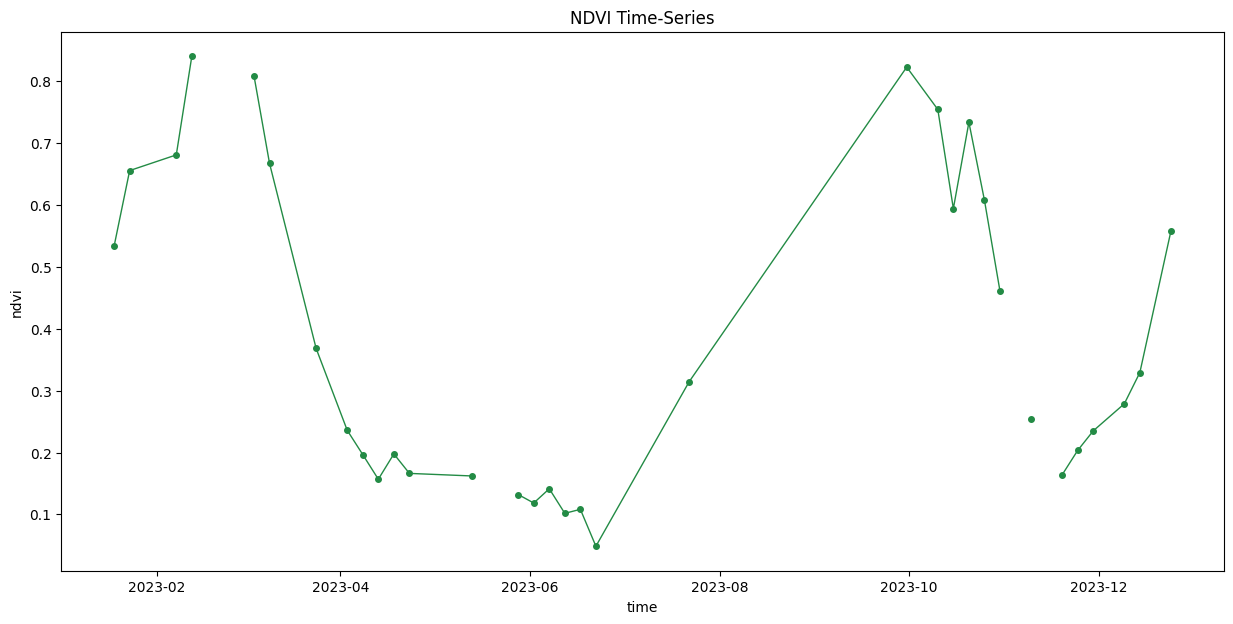

In [98]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 7)

time_series.plot.line(
    ax=ax, x='time',
    marker='o', color='#238b45',
    linestyle='-', linewidth=1, markersize=4)

# Format the x-axis to display dates as YYYY-MM
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

ax.set_title('NDVI Time-Series')
plt.show()

Close the dask client. This presents multiple clients being instantiated when running different notebooks on the same machine. This is not required on Colab but a good practice when you are running it on a local machine. Uncomment and run to shutdown the dask cluster.

In [ ]:
#client.shutdown()